<div align="center">
  <h1><strong><u>Forecasting the 10-Year U.S. Treasury Bond Interest Rate Using Macroeconomic Time Series and Factor Models</u></strong></h1>
  <h2>Michael Vazquez</h2>
  <h2>Rutgers University New Brunswick - Econ 570 Masters Project</h2>
  <h2>April 30, 2026</h2>
</div>
<h4>Github link: <br><a href="https://github.com/Vazquez-Michael-V/forecasting_econ_570/blob/main/project/econ_570_project.ipynb">https://github.com/Vazquez-Michael-V/forecasting_econ_570/blob/main/project/econ_570_project.ipynb</a></h4>


---

<div align="center">
    <h1><strong>#TODO: Abstract</strong></h1>
</div>


This project investigates whether applying PCA and factor models can produce lower MSFE
than the RW benchmark using only macroeconomic variables, excluding any bond market information.

Can macroeconomic factors predict the 10-year U.S. Treasury Bond interest rate beyond what
the random walk model captures using only the rate's own history?

*TODO - Write after results are complete. Key points to include:*
- *Data: monthly DGS10 and 17 macroeconomic variables from FRED, [dates TBD]*
- *Method: PCA factor model vs. RW benchmark*
- *Result: did the factor model beat the RW?*
- *Include the research question sentence from the Benchmark Model section*

---


<div align="center">
    <h1><strong>Introduction<strong></h1>
</div>


<div align="center">
  <h3><strong>Definition and Economic Significance of the 10-Year U.S. Treasury Bond Interest Rate</strong></h3>
</div>

The 10-year U.S. Treasury bond interest rate is the annualized return an investor earns on a U.S. government bond
maturing in 10 years. It is the most watched interest rate in the U.S. economy because almost
everything is priced relative to it:

- <i>Mortgage rates</i> track it closely - when the 10-year rate rises, mortgage rates rise, making
  homes less affordable.
- <i>Corporate borrowing costs</i> are set at a premium above the 10-year rate, so when it rises,
  business investment slows.
- <i>Equity markets</i> - higher rates make bonds more attractive relative to stocks, pulling money
  out of equities.
- <i>Federal Reserve policy</i> - the Fed directly controls the federal funds rate, the overnight
  lending rate between banks. The 10-year rate however is determined by the market, reflecting
  expectations about the path of short term rates, inflation, and real growth over the next decade.

Because the 10-year rate reflects the market's collective expectations about inflation, growth,
and Federal Reserve policy over the next decade, accurate forecasts of it have highly impactful
implications for mortgage markets, corporate borrowing, and investment decisions.

---


<div align="center">
    <h3><strong>Dataset and Timeframes</strong></h3>
</div>

The dataset consists of 18 monthly macroeconomic time series obtained from FRED over the
period January 2000 to December 2025, including the regressand `DGS10` and 17 macroeconomic
regressors detailed in Table 1. Forecasts will be made of the monthly 10-year U.S. Treasury
rate using the RW benchmark and factor models. For all models, the training timeframe is
January 2000 to December 2010, and the holdout timeframe is January 2011 to December 2025.
More concisely:

**Full timeframe:** 2000-01 to 2025-12, $T$ = 309 monthly observations.

**Training timeframe:** 2000-01 to 2010-12, $R$ = 131 monthly observations.

**Holdout timeframe:** 2011-01 to 2025-12, $P = T - R$ = 178 forecasts to be made.

*Note: The values of $T$, $R$, and $P$ are determined after data collection in Appendix 2.*


<div align="center">
    <h3><strong>Selecting Macroeconomic Time Series for Panel Data</strong></h3>
</div>

The 10-year Treasury rate reflects the market's expectations about future inflation, real
economic growth, and monetary policy over the next decade. Time series that contain
information about these expectations - such as industrial production, the federal funds
rate, and consumer prices - are therefore natural regressors in a forecasting model of the
10-year U.S. Treasury interest rate, forming the macroeconomic panel data for this project.
As discussed in the **Augmented Dickey-Fuller (ADF) Test for Stationarity to Avoid Spurious Regression** and **Determining Transformation Type** sections below,
all variables are transformed to achieve stationarity before modeling - percentages via first difference, and all level unit variables via log first difference.
Thus, the regressand is $z_t = \Delta\text{DGS10}_t$, the first difference of the 10-year
U.S. Treasury Bond interest rate, and the regressors are the transformed values of 17
macroeconomic variables from several different sectors of the economy, detailed in Table 1.

By design, none of the selected variables are bond market variables. If a factor model is
able to beat the RW using only macroeconomic variables, this shows that broad macroeconomic
conditions contain predictive information for the 10-year Treasury rate beyond what the
rate's own history provides.

**Endogeneity Rule:** No regressor is mechanically derived from or contains the 10-year
Treasury interest rate itself, with the exception of $z_{t-1}$, which is included in the
forecast equation to control for autocorrelation in the regressand as discussed in the
**Factor Model** section.

**Table 1.** Macroeconomic Panel Data

| # | FRED ID       | FRED Title                                                                                            | FRED Category                                   |
|---|---------------|-------------------------------------------------------------------------------------------------------|-------------------------------------------------|
| 0 | `DGS10`       | Market Yield on U.S. Treasury Securities at 10-Year Constant Maturity, Quoted on an Investment Basis | Treasury Constant Maturity                      |
| 1 | `AWHMAN`      | Average Weekly Hours of Production and Nonsupervisory Employees, Manufacturing                        | Manufacturing                                   |
| 2 | `CPIAUCSL`    | Consumer Price Index for All Urban Consumers: All Items in U.S. City Average                         | Consumer Price Indexes (CPI and PCE)            |
| 3 | `CPILFESL`    | Consumer Price Index for All Urban Consumers: All Items Less Food and Energy in U.S. City Average    | Special Indexes                                 |
| 4 | `DCOILWTICO`  | Crude Oil Prices: West Texas Intermediate (WTI) - Cushing, Oklahoma                                  | Commodities                                     |
| 5 | `FEDFUNDS`    | Federal Funds Effective Rate                                                                          | FRB Rates - discount, fed funds, primary credit |
| 6 | `HOUST`       | New Privately-Owned Housing Units Started: Total Units                                                | Housing Starts                                  |
| 7 | `ICSA`        | Initial Claims                                                                                        | Weekly Initial Claims                           |
| 8 | `INDPRO`      | Industrial Production: Total Index                                                                    | Industrial Production & Capacity Utilization    |
| 9 | `LOANS`       | Loans and Leases in Bank Credit, All Commercial Banks                                                 | All Commercial Banks                            |
| 10 | `M2SL`       | M2                                                                                                    | M2 and Components                               |
| 11 | `PAYEMS`      | All Employees, Total Nonfarm                                                                          | Total Nonfarm                                   |
| 12 | `PCEPI`       | Personal Consumption Expenditures: Chain-type Price Index                                             | Consumer Price Indexes (CPI and PCE)            |
| 13 | `RSAFS`       | Advance Retail Sales: Retail Trade and Food Services                                                  | Retail Trade                                    |
| 14 | `UMCSENT`     | University of Michigan: Consumer Sentiment                                                            | Financial Activity Measures                     |
| 15 | `UMTMTI`      | Manufacturers' Total Inventories: Total Manufacturing                                                 | Inventories                                     |
| 16 | `UNRATE`      | Unemployment Rate                                                                                     | Unemployment Rate                               |
| 17 | `VIXCLS`      | CBOE Volatility Index: VIX                                                                            | Volatility Indexes                              |

*Note: $z_{t-1}$ is included as an additional regressor in the forecast equation to control for autocorrelation in the regressand. It is derived from `DGS10` and is not a separate FRED series. See the **Factor Model** section for the full forecast equation.*

*Source: Federal Reserve Economic Data (FRED). See Appendix 1 for the code used to obtain this data.*

---

<div align="center">
    <h3><strong>Economic Intuition - Deliberate Multicollinearity of Price Variables</strong></h3>
</div>

To demonstrate the usefulness of economic intuition along with statistical rigor, three price variables - `CPIAUCSL`, `PCEPI`, `CPILFESL` - are intentionally included in the panel data. Considering that these three series all measure consumer prices, it appears likely that including all three in PCA would add noise without adding information. Before PCA, a correlation matrix is computed to statistically confirm this redundancy, then the single
price variable most correlated with `DGS10` is retained in the finalized macroeconomic panel, rather than simply passing all variables into PCA. The details of this are shown in **Appendix 4**.

---


<div align="center">
    <h3><strong>Augmented Dickey-Fuller (ADF) Test for Stationarity to Avoid Spurious Regression</strong></h3>
</div>

Regressing one non-stationary series on another leads to inaccurate forecasts and flawed analysis, as the regression appears significant only because both series trend together, not because of any actual economic relationship. A standard method to address non-stationarity and spurious regression is to apply the log first difference transformation to the panel data before PCA and regression. The "log first difference" is defined as:

$$\Delta \ln(x_t) = \ln(x_t) - \ln(x_{t-1})$$

This is equivalent to $\ln(x_t / x_{t-1})$, the continuously compounded monthly growth rate of $x_t$, which is stationary and economically interpretable. Note that this is NOT the same as taking the difference first and then logging, i.e. $\ln(x_t - x_{t-1})$, which has no clean
economic interpretation and fails entirely when the difference is negative.

Two transformations are applied depending on the units of each variable. For variables in levels units - prices, quantities, indices - the log first difference allows the data to be interpreted in terms of growth rates:

$$\Delta \ln(x_t) = \ln(x_t) - \ln(x_{t-1})$$

For variables already in percentage units - `DGS10`, `FEDFUNDS`, `UNRATE` - the log first difference is not appropriate. The log first difference approximates $\frac{x_t - x_{t-1}}{x_{t-1}}$, the proportional change in $x_t$. For a variable already measured in percent, this gives the proportional change of a percentage, which has no meaningful economic interpretation. The simple first difference is therefore
applied:

$$\Delta x_t = x_t - x_{t-1}$$

A series $x_t$ is said to be $I(d)$ if it must be differenced $d$ times to become stationary. In this project, only $I(0)$ and $I(1)$ series are used.

- $I(0)$ - stationary in levels, no differencing needed
- $I(1)$ - stationary after one difference, i.e. $\Delta x_t = x_t - x_{t-1}$

Stationarity after transformation is verified using the Augmented Dickey-Fuller (ADF) test.
The null hypothesis of the ADF test is that the series contains a unit root, i.e. is
non-stationary. A p-value below a specified significance level, typically 5 or 10 percent, allows us to reject the null hypothesis and conclude
the series is stationary.

---



<div align="center">
    <h3><strong>Determining Transformation Type</strong></h3>
</div>

The correct transformation for each variable is determined programmatically using the FRED API
before any data transformation is applied:

```python
fred.get_series_info(series_id)['units']
```

This returns the official units string for each series directly from FRED, eliminating
guesswork and ensuring no nonsensical transformation is applied to any variable.

**Table 2.** Variables Units and Transformation

| # | FRED ID       | FRED Units               | Transformation       | Variable Type |
|---|---------------|--------------------------|----------------------|---------------|
| 0 | `DGS10`       | Percent                  | First Difference     | Regressand    |
| 1 | `AWHMAN`      | Hours                    | Log First Difference | Regressor     |
| 2 | `CPIAUCSL`    | Index 1982-1984=100      | Log First Difference | Regressor     |
| 3 | `CPILFESL`    | Index 1982-1984=100      | Log First Difference | Regressor     |
| 4 | `DCOILWTICO`  | Dollars per Barrel       | Log First Difference | Regressor     |
| 5 | `FEDFUNDS`    | Percent                  | First Difference     | Regressor     |
| 6 | `HOUST`       | Thousands of Units       | Log First Difference | Regressor     |
| 7 | `ICSA`        | Number                   | Log First Difference | Regressor     |
| 8 | `INDPRO`      | Index 2017=100           | Log First Difference | Regressor     |
| 9 | `LOANS`       | Billions of U.S. Dollars | Log First Difference | Regressor     |
| 10 | `M2SL`       | Billions of Dollars      | Log First Difference | Regressor     |
| 11 | `PAYEMS`      | Thousands of Persons     | Log First Difference | Regressor     |
| 12 | `PCEPI`       | Index 2017=100           | Log First Difference | Regressor     |
| 13 | `RSAFS`       | Millions of Dollars      | Log First Difference | Regressor     |
| 14 | `UMCSENT`     | Index 1966:Q1=100        | Log First Difference | Regressor     |
| 15 | `UMTMTI`      | Millions of Dollars      | Log First Difference | Regressor     |
| 16 | `UNRATE`      | Percent                  | First Difference     | Regressor     |
| 17 | `VIXCLS`      | Index                    | Log First Difference | Regressor     |

*Note: $z_{t-1}$ is included as an additional regressor in the forecast equation to control for autocorrelation in the regressand. It is derived from `DGS10` and is not a separate FRED series. See the **Factor Model** section for the full forecast equation.*

*Source: Federal Reserve Economic Data (FRED). See Appendix 1 for the code used to obtain this data.*

---



<div align="center">
    <h3><strong>Vintage Data and Reproducibility</strong></h3>
</div>

FRED occasionally revises historical data series as new information becomes available. To ensure
that this analysis is fully reproducible regardless of future data revisions, all series are
pulled using a set vintage date via the ALFRED (Archival FRED) database:

```python
FRED_REALTIME_DATE = '2026-04-17'

fred.get_series(series_id,
                observation_start='2000-01-01',
                observation_end='2025-12-31',
                realtime_start=FRED_REALTIME_DATE,
                realtime_end=FRED_REALTIME_DATE)
```

Setting `realtime_start` and `realtime_end` to the same date returns the data exactly as it
existed in the FRED database on that date. Any future revisions to the underlying series will
not affect the results of this analysis.

*See Appendix 2 for full code on this.*

<div align="center">
    <h3><strong>Loss Functions and MSFE</strong></h3>
</div>

Loss functions measure forecast accuracy and allow for model comparison. Following Swanson (Lecture 7, Econ 570, Spring 2026), the primary loss function used in this project is Mean Squared Forecast Error (MSFE), derived from quadratic loss $L(e) \propto e^2$, which penalizes large errors disproportionately:

$$\text{MSFE} = \frac{1}{P}\sum_{t=R}^{T-1}\left(z_{t+1} - \hat{z}_{t+1|t}\right)^2$$

where:
- $T$ is the total number of observations
- $R$ is the number of training observations
- $P = T - R$ is the number of out-of-sample forecasts in the holdout period
- $\hat{z}_{t+1|t}$ is the $h = 1$ month-ahead forecast of $\Delta\text{DGS10}$ made at origin $t$
- $z_{t+1}$ is the realized value of $\Delta\text{DGS10}$ at time $t+1$

Generally, a model is said to be **"preferred to"** or **"beats"** another model if it produces a lower MSFE over the holdout period. Specifically in this project, a factor model is said to beat another model, the benchmark model defined in the following section, if it produces a lower MSFE over the holdout period.

<div align="center">
    <h3><strong>Benchmark Model</strong></h3>
</div>

As noted in Swanson (Lecture 7, Econ 570, Spring 2026), the Random Walk (RW) is a natural benchmark for interest rate forecasting. The RW forecast assigns all weight to the most recent observation, and its optimality follows from the Efficient Markets Hypothesis - if an asset price reflects all available information, the best forecast of its next value is simply its current value. This is further supported by Swanson (Lecture 22, Econ 570, Spring 2026), where the RW is used as a strawman model when forecasting U.S. Treasury yields at horizons of $h = 1$, $3$, and $12$ months, which includes the same $h = 1$ month horizon as this project. Empirically, the RW was also the best performing model in the midterm Vazquez (Midterm, Econ 570, Spring 2026), where it achieved the lowest MSFE at $h = 1$ week among five naive models for the weekly 10-year U.S. Treasury rate.

Because this project operates at monthly frequency, the midterm MSFE cannot be used directly. The RW MSFE is therefore recomputed over this project's holdout period and used as a benchmark for the factor models to beat.

Since `DGS10` is $I(1)$ and $\Delta\text{DGS10}$ is $I(0)$, as confirmed by the ADF test
in **Appendix 3**, all modeling is performed on the first differenced series <br>
$z_t = \Delta\text{DGS10}_t = \text{DGS10}_t - \text{DGS10}_{t-1}$. The RW in levels
states $\widehat{\text{DGS10}}_{t+1|t} = \text{DGS10}_t$, which in first differences is
equivalently:

$$\hat{z}_{t+1|t} = 0$$

The Random Walk therefore forecasts no change in the 10-year Treasury rate each month.

---

<div align="center">
    <h3><strong>Factor Model</strong></h3>
</div>

Following Stock and Watson (2002) and Swanson (Lecture 19, Econ 570, Spring 2026), this
project uses the diffusion index model to forecast the 10-year U.S. Treasury rate. The
model consists of two equations. The first is the approximate factor model for the
macroeconomic panel, as presented in Stock and Watson (2002, eq. 1):

$$X_t = \Lambda F_t + e_t$$

where:
- $X_t$ is the $N \times 1$ vector of transformed macroeconomic regressors at time $t$
- $\Lambda$ is the $N \times r$ matrix of factor loadings
- $F_t$ is the $r \times 1$ vector of common latent factors, where $r << N$
- $e_t$ is the $N \times 1$ vector of idiosyncratic disturbances

The factors $F_t$ are unobserved and are estimated via Principal Component Analysis (PCA)
on the standardized panel $X_t$, following Swanson (Lecture 18, Econ 570, Spring 2026)
and Stock and Watson (2002, sec. 2.2). The second equation uses the estimated factors
$\hat{F}_t$ together with a lag of the regressand to forecast $z_{t+1}$, following Stock
and Watson (2002, eq. 2):

$$z_{t+1} = \beta_F' \hat{F}_t + \beta_w z_{t-1} + \varepsilon_{t+1}$$

where:
- $z_t = \Delta\text{DGS10}_t = \text{DGS10}_t - \text{DGS10}_{t-1}$ is the first
  difference of the 10-year U.S. Treasury rate, $I(0)$ as confirmed by the ADF test
  in Appendix 3
- $z_{t+1}$ is the realized value of $\Delta\text{DGS10}$ at time $t+1$
- $\hat{F}_t$ is the $r \times 1$ vector of estimated factors at time $t$
- $\beta_F$ is the $r \times 1$ vector of coefficients on the factors, estimated by OLS
- $z_{t-1}$ is the lagged value of $z_t$, included to control for autocorrelation in
  the regressand as discussed in Swanson (Lecture 6, Econ 570, Spring 2026)
- $\beta_w$ is the scalar coefficient on $z_{t-1}$, estimated by OLS
- $\varepsilon_{t+1}$ is the forecast error at horizon $h = 1$ month

The $h = 1$ month-ahead forecast at origin $t$ is therefore:

$$\hat{z}_{t+1|t} = \hat{\beta}_F' \hat{F}_t + \hat{\beta}_w z_{t-1}$$

The number of factors $r$ is selected by minimizing MSFE over the holdout period across
$r \in \{1, 2, 3, 4\}$, as discussed in Appendix 5 and Appendix 6.


<div align="center">
    <h1><strong>TODO: Methodology and Empirical Results<strong></h1>
</div>

<div align="center">
    <h3><strong>Economic Intuition - Deliberate Multicollinearity of Price Variables</strong></h3>
</div>

The three price variables (`CPIAUCSL`, `PCEPI`, `CPILFESL`) are intentionally included in the panel data despite being highly correlated, as all three measure consumer prices. Before PCA, a correlation matrix is computed to statistically confirm this redundancy. As shown in
**Appendix 4**, `CPIAUCSL` and `PCEPI` have a correlation of 0.9373, confirming they are nearly identical measures of consumer prices. `CPILFESL`, which excludes food and energy, is more distinct at 0.4694 and 0.4640 correlation with the other two price variables respectively.

Correlation with `DGS10` is then used to select which single price variable to retain. `PCEPI` has the highest absolute correlation with `DGS10` at 0.2986, slightly above `CPIAUCSL` at 0.2967, with `CPILFESL` the weakest at 0.1687. `PCEPI` is therefore retained and `CPIAUCSL` and `CPILFESL` are dropped, leaving 16 variables in the final macroeconomic
panel. This procedure demonstrates the use of economic intuition and statistical rigor in variable selection rather than simply passing all variables into PCA.

---


# Appendix 0 - Code Preliminaries

The code in all following appendixes depend upon the code in Appendix 0. This is the technical setup before pulling any FRED data, or performing any statistical analysis, or creating forecasts, etc.

## Imports and Settings.

In [70]:

import pandas as pd
import numpy as np
import scipy.stats

import statsmodels.formula.api as smf
from statsmodels.tsa.stattools import adfuller

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

from IPython.display import display, Math, Image

import os

import requests

# Can use types library to add to fred instance, but not really necessary to do so.
# import types

import io

# FRED Python library.
from fredapi import Fred


# Module that I made for summary statistics of interest to Econ 570.
# More functions may be added later in the course.
from econ_570_mod.summary_statistics import summary_statistics


# The 'cm' font nicely displays Greek characters.
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'mathtext.fontset': 'cm',
    'axes.grid': True,
    'grid.alpha': 0.35,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

%matplotlib inline


## Functions.

In [71]:
def get_fred_categories(series_id):
    url = f"https://api.stlouisfed.org/fred/series/categories"
    params = {
        'series_id': series_id,
        'api_key': os.environ.get('FRED_API_KEY'),
        'file_type': 'json'
    }
    response = requests.get(url, params=params)
    
    try:
        assert response.status_code == 200, "Response status code is not 200."
    except AssertionError as e:
        print(response.status_code)
        print(response.reason)
        raise e
    
    return pd.DataFrame(response.json()['categories'])


## Notebook variables.

In [72]:

#############################################################################
# FRED notebook variables.
FRED_API_KEY = os.getenv("FRED_API_KEY")

# Use these variables for setting the start and end dates of data pulls from FRED.
FRED_OBS_START_DATE = '2000-01-01'
FRED_OBS_END_DATE = '2025-12-31'

# Use FRED_REALTIME_DATE for reproducible results. This will obtain the data from the FRED
# database exactly as it appeared on that date. ie if FRED revises economic data in 2027,
# my analysis performed in late April 2026 will still be valid with respect to FRED_REALTIME_DATE.
FRED_REALTIME_DATE = '2026-04-17'

# Place all of the FRED time series in a list.
# dgs10 is the regressand 10-year U.S. Treasury interest rate. All others are regressors.
FRED_TIME_SERIES_LIST = [
    'DGS10',
    'FEDFUNDS',
    'UNRATE',
    'INDPRO',
    'PAYEMS',
    'RSAFS',
    'AWHMAN',
    'UMTMTI',
    'CPIAUCSL',
    'PCEPI',
    'CPILFESL',
    'VIXCLS',
    'DCOILWTICO',
    'M2SL',
    'HOUST',
    'UMCSENT',
    'LOANS',
    'ICSA'
]

assert not pd.Series(FRED_TIME_SERIES_LIST).duplicated().any(), "FRED_TIME_SERIES_LIST contains duplicates."

# Create an instance of Fred. This serves as the connection to the FRED API.
fred = Fred(api_key=FRED_API_KEY)
# Fred library does not have a wrapper on the categories endpoint, so add it here.
# This isn't necessary, can simply call get_series_categories() when needed. It doesn't need
# to be added to the fred instance.
# fred.get_series_categories = types.MethodType(get_fred_categories, fred)

#############################################################################


# Output directory of the project.
PROJECT_DIR = os.environ.get('ECON_570_PROJECT_DIR')

# Maximum number of nulls allowed after pulling data from FRED.
MAX_ALLOWED_NULLS = 3


#############################################################################
# These dates will be used when forecasting.
TRAIN_START = '2000-01-01'
TRAIN_END = '2010-12-31'
HOLD_START = '2011-01-01'
HOLD_END = '2025-12-31'
#############################################################################



# Appendix 1 - The Details of Each Selected Time Series via FRED API

Obtain official FRED information and category of each selected macroeconomic time series, using this data for the following purposes:
- Confirm that each time series makes sense in the model.
- Confirm that each time series has frequency daily, weekly, or monthly. This is required to ensure all time series can be accurately obtained from FRED at the monthly frequency.
- Check the unit of each time series to determine the transformation type, first difference or log first difference. Time series in unit 'Percent' get first differenced, and all others get log first differenced.

## 1.1 - FRED information. The frequency of each time series is available via `fred.get_series_info(series_id)`, which allows me to confirm the validity of `frequency='m'` when pulling FRED data.

In [73]:

series_info_dfs_list = []
for series_id in FRED_TIME_SERIES_LIST:
    ser = fred.get_series_info(series_id)
    # print(ser.index)
    title = ser.loc['title']
    units = ser.loc['units']
    units_short = ser.loc['units_short']
    frequency = ser.loc['frequency']
    frequency_short = ser.loc['frequency_short']
    df = pd.DataFrame([{
        'series_id': series_id,
        'title': title,
        'units': units,
        'units_short': units_short,
        'frequency': frequency,
        'frequency_short': frequency_short
    }])
    series_info_dfs_list.append(df)
df_series_info = pd.concat(series_info_dfs_list).reset_index(drop=True)

# In the API pull, frequency='m' was specified. Here I check that the units of each series
# are such that aggregating to monthly frequency without upsampling is possible, or that the series is
# already at a monthly frequency.
df_series_info = df_series_info.assign(
    valid_frequency = df_series_info['frequency_short'].str.contains(r'^D$|^W$|^M$', regex=True)
)

display(df_series_info)
assert df_series_info['valid_frequency'].all(), "At least one series has an invalid frequency."
print("The frequencies of all time series are as expected - daily, weekly, or monthly.")


,series_id,title,units,units_short,frequency,frequency_short,valid_frequency
0,DGS10,Market Yield on U.S. Treasury Securities at 10...,Percent,%,Daily,D,True
1,FEDFUNDS,Federal Funds Effective Rate,Percent,%,Monthly,M,True
2,UNRATE,Unemployment Rate,Percent,%,Monthly,M,True
3,INDPRO,Industrial Production: Total Index,Index 2017=100,Index 2017=100,Monthly,M,True
4,PAYEMS,"All Employees, Total Nonfarm",Thousands of Persons,Thous. of Persons,Monthly,M,True
5,RSAFS,Advance Retail Sales: Retail Trade and Food Se...,Millions of Dollars,Mil. of $,Monthly,M,True
6,AWHMAN,Average Weekly Hours of Production and Nonsupe...,Hours,Hours,Monthly,M,True
7,UMTMTI,Manufacturers' Total Inventories: Total Manufa...,Millions of Dollars,Mil. of $,"Monthly, End of Period",M,True
8,CPIAUCSL,Consumer Price Index for All Urban Consumers: ...,Index 1982-1984=100,Index 1982-1984=100,Monthly,M,True
9,PCEPI,Personal Consumption Expenditures: Chain-type ...,Index 2017=100,Index 2017=100,Monthly,M,True


The frequencies of all time series are as expected - daily, weekly, or monthly.


## 1.2 - FRED categories.

In [74]:
fred_cats_dfs_list = []
for series_id in FRED_TIME_SERIES_LIST:
    df = get_fred_categories(series_id)
    df = df.assign(
        # I confirmed this does not overwrite any FRED field names.
        series_id=series_id
    )
    fred_cats_dfs_list.append(df)
df_fred_cats = pd.concat(fred_cats_dfs_list).reset_index(drop=True)

# It turns out that a series can belong to multiple categories. Pick the most descriptive
# category, ie the category having the longest string length.
df_fred_cats = (
    df_fred_cats
    # String length of the category name.
    .assign(
        name_len = df_fred_cats['name'].str.len()
    )
    .sort_values(
        by=['series_id', 'name_len'],
        ascending=[True, False]
    )
    # This keeps the first category, per the series_id and name_len sort ASC, DESC.
    .drop_duplicates(
        subset=['series_id']
    )
    # Keep only the columns required for categorizing the series.
    .drop(
        columns=['id', 'parent_id', 'notes', 'name_len']
    )
    # Can rename here without conern of overwriting FRED field names.
    .rename(
        columns={
            'name': 'category',
        },
        errors='raise'
    )
    .reset_index(drop=True)
)

assert df_fred_cats.shape[0] == len(FRED_TIME_SERIES_LIST), "Number of rows in df_fred_cats should match length of FRED_TIME_SERIES_LIST."

display(df_fred_cats)


,category,series_id
0,Manufacturing,AWHMAN
1,Consumer Price Indexes (CPI and PCE),CPIAUCSL
2,Special Indexes,CPILFESL
3,Commodities,DCOILWTICO
4,Treasury Constant Maturity,DGS10
5,"FRB Rates - discount, fed funds, primary credit",FEDFUNDS
6,Housing Starts,HOUST
7,Weekly Initial Claims,ICSA
8,Industrial Production & Capacity Utilization,INDPRO
9,All Commercial Banks,LOANS


## 1.3 - Left merge FRED information df_series_info with FRED categories df_fred_cats on series_id.

In [75]:
df_series_info = pd.merge(
    df_series_info,
    df_fred_cats,
    how='left',
    on=['series_id'],
    validate='1:1'
)

display(df_series_info)

,series_id,title,units,units_short,frequency,frequency_short,valid_frequency,category
0,DGS10,Market Yield on U.S. Treasury Securities at 10...,Percent,%,Daily,D,True,Treasury Constant Maturity
1,FEDFUNDS,Federal Funds Effective Rate,Percent,%,Monthly,M,True,"FRB Rates - discount, fed funds, primary credit"
2,UNRATE,Unemployment Rate,Percent,%,Monthly,M,True,Unemployment Rate
3,INDPRO,Industrial Production: Total Index,Index 2017=100,Index 2017=100,Monthly,M,True,Industrial Production & Capacity Utilization
4,PAYEMS,"All Employees, Total Nonfarm",Thousands of Persons,Thous. of Persons,Monthly,M,True,Total Nonfarm
5,RSAFS,Advance Retail Sales: Retail Trade and Food Se...,Millions of Dollars,Mil. of $,Monthly,M,True,Retail Trade
6,AWHMAN,Average Weekly Hours of Production and Nonsupe...,Hours,Hours,Monthly,M,True,Manufacturing
7,UMTMTI,Manufacturers' Total Inventories: Total Manufa...,Millions of Dollars,Mil. of $,"Monthly, End of Period",M,True,Inventories
8,CPIAUCSL,Consumer Price Index for All Urban Consumers: ...,Index 1982-1984=100,Index 1982-1984=100,Monthly,M,True,Consumer Price Indexes (CPI and PCE)
9,PCEPI,Personal Consumption Expenditures: Chain-type ...,Index 2017=100,Index 2017=100,Monthly,M,True,Consumer Price Indexes (CPI and PCE)


## 1.4 - Add variable type and transformation type to df_series_info.

In [76]:

# Create a categorical column to indicate how a series is used in the model.
df_series_info = df_series_info.assign(
    variable_type = 'regressor'
)
df_series_info.loc[(df_series_info['series_id'] == 'DGS10'), 'variable_type'] = 'regressand'
var_cat_dtype = pd.api.types.CategoricalDtype(
    categories=['regressand', 'regressor'], ordered=True
)
df_series_info['variable_type'] = df_series_info['variable_type'].astype(var_cat_dtype)

# Transformation conditions.
transform_cond_list = [
    df_series_info['units'] == 'Percent'
]
transform_choice_list = [
    'first_difference'
]
df_series_info = df_series_info.assign(
    transform_type = np.select(transform_cond_list, transform_choice_list, default='log_first_difference')
)

df_series_info = df_series_info.sort_values(by=['variable_type', 'series_id', 'title']).reset_index(drop=True)

display(df_series_info)

with pd.ExcelWriter(rf"{PROJECT_DIR}\\df_series_info.xlsx") as writer:
    df_series_info.to_excel(writer, sheet_name='time_series_info', index=False)


,series_id,title,units,units_short,frequency,frequency_short,valid_frequency,category,variable_type,transform_type
0,DGS10,Market Yield on U.S. Treasury Securities at 10...,Percent,%,Daily,D,True,Treasury Constant Maturity,regressand,first_difference
1,AWHMAN,Average Weekly Hours of Production and Nonsupe...,Hours,Hours,Monthly,M,True,Manufacturing,regressor,log_first_difference
2,CPIAUCSL,Consumer Price Index for All Urban Consumers: ...,Index 1982-1984=100,Index 1982-1984=100,Monthly,M,True,Consumer Price Indexes (CPI and PCE),regressor,log_first_difference
3,CPILFESL,Consumer Price Index for All Urban Consumers: ...,Index 1982-1984=100,Index 1982-1984=100,Monthly,M,True,Special Indexes,regressor,log_first_difference
4,DCOILWTICO,Crude Oil Prices: West Texas Intermediate (WTI...,Dollars per Barrel,$ per Barrel,Daily,D,True,Commodities,regressor,log_first_difference
5,FEDFUNDS,Federal Funds Effective Rate,Percent,%,Monthly,M,True,"FRB Rates - discount, fed funds, primary credit",regressor,first_difference
6,HOUST,New Privately-Owned Housing Units Started: Tot...,Thousands of Units,Thous. of Units,Monthly,M,True,Housing Starts,regressor,log_first_difference
7,ICSA,Initial Claims,Number,Number,"Weekly, Ending Saturday",W,True,Weekly Initial Claims,regressor,log_first_difference
8,INDPRO,Industrial Production: Total Index,Index 2017=100,Index 2017=100,Monthly,M,True,Industrial Production & Capacity Utilization,regressor,log_first_difference
9,LOANS,"Loans and Leases in Bank Credit, All Commercia...",Billions of U.S. Dollars,Bil. of U.S. $,Monthly,M,True,All Commercial Banks,regressor,log_first_difference


# Appendix 2 - Data Collection of Each Time Series via FRED API

Use the FRED API to pull economic time series data, checking timeframes and null values.

In [77]:

# fred.get_series() returns a pandas Series. Thus the dictionary {series_id_0: pd.Series_0, ..., series_id_n: pd.Series_n}
# gets passed to the DataFrame constructor for each i, 0 <= i <= n, where n is the number of macroeconomic variables,
# ie the length of FRED_TIME_SERIES_LIST.
df_fred = pd.DataFrame({
    series_id: fred.get_series(
        series_id,
        frequency='m',
        observation_start=FRED_OBS_START_DATE,
        observation_end=FRED_OBS_END_DATE,
        realtime_start=FRED_REALTIME_DATE,
        realtime_end=FRED_REALTIME_DATE
        )
    for series_id in FRED_TIME_SERIES_LIST
})

# The index of DataFrame df_fred will be the union of the indexes of each pandas Series.
# Ensure the dates are as expected.
assert (df_fred.index == pd.date_range(start=FRED_OBS_START_DATE, end=FRED_OBS_END_DATE, freq='MS')).all(),\
    "Dates are not as expected."

# Ensure every series has observations starting at FRED_OBS_START_DATE.
assert df_fred.apply(lambda x: x.first_valid_index()).unique() == [pd.Timestamp(FRED_OBS_START_DATE)],\
    f"The first valid index of each time series must be {FRED_OBS_START_DATE}."

# Display nulls by series and enforce MAX_ALLOWED_NULLS.
df_null_count = (
    df_fred
    .isna()
    .sum()
    .to_frame()
    .reset_index()
    .rename(columns={'index': 'series_name', 0: 'null_count'})
)
display(df_null_count.query("null_count > 0"))
found_nulls = df_null_count['null_count'].sum()
assert found_nulls <= MAX_ALLOWED_NULLS, f"No more than {MAX_ALLOWED_NULLS} null values are allowed in df_fred, found {found_nulls}."

# Name the index for plotting purposes.
df_fred.index.name = 'date'

print(f"df_fred shape: {df_fred.shape}")
print("df_fred info:")
print(df_fred.info(show_counts=True, verbose=True))
display(df_fred.sample(n=5))

# Doesn't hurt to output the data to excel.
with pd.ExcelWriter(rf"{PROJECT_DIR}\\df_fred.xlsx") as writer:
    df_fred.to_excel(writer, sheet_name='panel_data_levels')


,series_name,null_count
2,UNRATE,1
8,CPIAUCSL,1
10,CPILFESL,1


df_fred shape: (312, 18)
df_fred info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 312 entries, 2000-01-01 to 2025-12-01
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DGS10       312 non-null    float64
 1   FEDFUNDS    312 non-null    float64
 2   UNRATE      311 non-null    float64
 3   INDPRO      312 non-null    float64
 4   PAYEMS      312 non-null    float64
 5   RSAFS       312 non-null    float64
 6   AWHMAN      312 non-null    float64
 7   UMTMTI      312 non-null    float64
 8   CPIAUCSL    311 non-null    float64
 9   PCEPI       312 non-null    float64
 10  CPILFESL    311 non-null    float64
 11  VIXCLS      312 non-null    float64
 12  DCOILWTICO  312 non-null    float64
 13  M2SL        312 non-null    float64
 14  HOUST       312 non-null    float64
 15  UMCSENT     312 non-null    float64
 16  LOANS       312 non-null    float64
 17  ICSA        312 non-null    float64
dtypes: float64(1

,DGS10,FEDFUNDS,UNRATE,INDPRO,PAYEMS,RSAFS,AWHMAN,UMTMTI,CPIAUCSL,PCEPI,CPILFESL,VIXCLS,DCOILWTICO,M2SL,HOUST,UMCSENT,LOANS,ICSA
date,,,,,,,,,,,,,,,,,,
2014-09-01,2.53,0.09,5.9,103.0641,139563.0,430189.0,42.1,649442.0,237.477,97.413,238.786,13.47,93.21,11519.1,1023.0,84.6,7480.9966,295000.0
2018-09-01,3.00,1.95,3.7,104.1004,149358.0,491507.0,42.0,681490.0,252.182,102.418,258.368,12.91,70.23,14245.5,1250.0,100.1,9435.7305,205200.0
2006-02-01,4.57,4.49,4.8,98.2413,135733.0,347021.0,41.0,483672.0,199.400,83.584,203.600,12.47,61.63,6754.7,2119.0,86.7,5289.0309,290750.0
2016-06-01,1.64,0.38,4.9,98.8833,144147.0,450237.0,41.8,627742.0,240.222,98.325,247.540,17.77,48.76,12852.5,1203.0,93.5,8572.6026,265250.0
2018-05-01,2.98,1.70,3.8,102.4024,148742.0,491960.0,42.1,673156.0,250.792,101.941,257.145,14.12,69.98,14092.4,1357.0,98.0,9299.0105,221250.0


# Appendix 3 - Address Issues of Non-Stationarity and Spurious Regression

Since the benchmark model is a Random Walk using only the 10-year rate's history to create forecasts, it is possible that each macroeconomic time series in the panel data can individually also be forecasted using the Random Walk model, which would lead to spurious regression. To avoid this issue, all variables are transformed from levels to growth rates via the difference operator. Variables in units of percent are first differenced, and all other variables are log first differenced.

## Apply the first difference and log first difference transformations.

In [78]:
DIFFERENCE_COLS = df_series_info.loc[(df_series_info['transform_type'] == 'first_difference'), 'series_id'].to_list()
print("The following columns will be simple differenced:")
for col in DIFFERENCE_COLS:
    print(col)
print()

LOG_DIFFERENCE_COLS = [col for col in df_fred.columns if col not in DIFFERENCE_COLS]
print("The following columns will be log differenced:")
for col in LOG_DIFFERENCE_COLS:
    print(col)
print()

df_transformed = df_fred.copy()
df_transformed = (
    df_transformed
    .apply(lambda x: x.diff() if x.name in DIFFERENCE_COLS else x)
    .apply(lambda x: np.log(x).diff() if x.name in LOG_DIFFERENCE_COLS else x)
    .dropna()
)

print(f"\ndf_transformed shape: {df_transformed.shape}")
print("df_transformed info:")
print(df_transformed.info(show_counts=True, verbose=True))
display(df_transformed.head())


The following columns will be simple differenced:
DGS10
FEDFUNDS
UNRATE

The following columns will be log differenced:
INDPRO
PAYEMS
RSAFS
AWHMAN
UMTMTI
CPIAUCSL
PCEPI
CPILFESL
VIXCLS
DCOILWTICO
M2SL
HOUST
UMCSENT
LOANS
ICSA


df_transformed shape: (309, 18)
df_transformed info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 309 entries, 2000-02-01 to 2025-12-01
Data columns (total 18 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DGS10       309 non-null    float64
 1   FEDFUNDS    309 non-null    float64
 2   UNRATE      309 non-null    float64
 3   INDPRO      309 non-null    float64
 4   PAYEMS      309 non-null    float64
 5   RSAFS       309 non-null    float64
 6   AWHMAN      309 non-null    float64
 7   UMTMTI      309 non-null    float64
 8   CPIAUCSL    309 non-null    float64
 9   PCEPI       309 non-null    float64
 10  CPILFESL    309 non-null    float64
 11  VIXCLS      309 non-null    float64
 12  DCOILWTICO  309 

,DGS10,FEDFUNDS,UNRATE,INDPRO,PAYEMS,RSAFS,AWHMAN,UMTMTI,CPIAUCSL,PCEPI,CPILFESL,VIXCLS,DCOILWTICO,M2SL,HOUST,UMCSENT,LOANS,ICSA
date,,,,,,,,,,,,,,,,,,
2000-02-01,-0.14,0.28,0.1,0.003118,0.000832,0.015709,0.000000,0.016486,0.004126,0.003147,0.000558,0.017094,0.074553,0.002845,0.059905,-0.006270,0.008681,0.018381
2000-03-01,-0.26,0.12,-0.1,0.003549,0.003684,0.012467,-0.002413,-0.011110,0.005865,0.004281,0.003339,-0.038001,0.015876,0.006558,-0.079659,-0.038466,0.011606,-0.066867
2000-04-01,-0.27,0.17,-0.2,0.005935,0.002125,-0.018579,0.004819,0.014173,-0.000585,-0.000830,0.001665,0.178500,-0.148581,0.011836,0.013623,0.019418,0.010482,-0.011531
2000-05-01,0.45,0.25,0.2,0.002704,0.001674,0.007263,-0.009662,0.003467,0.001754,0.000830,0.002216,-0.029518,0.112759,-0.002541,-0.031868,0.013643,0.012365,0.038463
2000-06-01,-0.34,0.26,0.0,0.000390,-0.000318,0.006587,0.002424,-0.005367,0.005824,0.003382,0.002211,-0.202315,0.100067,0.003757,-0.010211,-0.039618,0.009522,0.030530


## Perform ADF checks.

In [79]:
adf_dfs_list = []
for col in df_transformed.columns:
    result = adfuller(df_transformed[col])
    df = pd.DataFrame([{'series_name': col, 'adf': result[0], 'pvalue': result[1]}])
    adf_dfs_list.append(df)
df_adf = pd.concat(adf_dfs_list).reset_index(drop=True).sort_values(by=['pvalue'], ascending=False).round(4)
display(df_adf)
assert df_adf['pvalue'].max() < 0.10, "Non-stationarity issues still persist at the 10% significance level."

,series_name,adf,pvalue
10,CPILFESL,-2.7574,0.0646
8,CPIAUCSL,-3.2002,0.0200
7,UMTMTI,-3.9119,0.0019
1,FEDFUNDS,-4.0699,0.0011
5,RSAFS,-4.8954,0.0000
13,M2SL,-5.0553,0.0000
11,VIXCLS,-6.5409,0.0000
17,ICSA,-9.3020,0.0000
15,UMCSENT,-10.2242,0.0000
9,PCEPI,-10.2473,0.0000


#### Augmented Dickey-Fuller test results
At the 10% significance level, the null hypothesis of a unit root is rejected for all 18
transformed series, confirming that all series are $I(1)$ in levels and $I(0)$ after
applying the appropriate first difference transformation.

# Appendix 4 - Applying Economic Intuition with Statistical Rigor Before PCA

Using economic intuition, I suspect that the three price time series (`CPIAUCSL`, `PCEPI`, `CPILFESL`) are highly correlated since all three of these time series are a measure of consumer prices. If this is true, then including all three price variables in PCA adds noise without adding information. Before PCA, the correlation matrix is used to statistically confirm this redundancy, then the single price variable most correlated with `DGS10` is retained in the finalized macroeconomic panel. The other two price variables are dropped before PCA.

Correlation matrix of price variables:


,CPIAUCSL,PCEPI,CPILFESL
CPIAUCSL,1.0000,0.9373,0.4694
PCEPI,0.9373,1.0000,0.4640
CPILFESL,0.4694,0.4640,1.0000


Correlation of price variables with DGS10:


CPIAUCSL    0.2967
PCEPI       0.2986
CPILFESL    0.1687
Name: Correlation with DGS10, dtype: float64

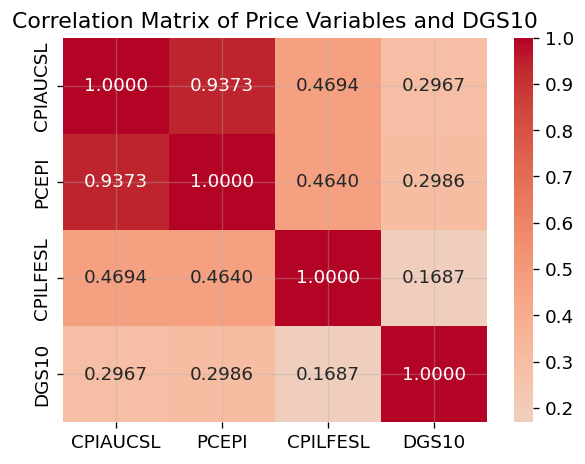


Price variable retained: PCEPI
Price variables dropped: ['CPIAUCSL', 'CPILFESL']
df_transformed shape after dropping price variables: (309, 16)


In [80]:
price_cols = ['CPIAUCSL', 'PCEPI', 'CPILFESL']

# Correlation among the three price variables.
print('Correlation matrix of price variables:')
display(df_transformed[price_cols].corr().round(4))

# Correlation of each price variable with DGS10.
print('Correlation of price variables with DGS10:')
display(df_transformed[price_cols].corrwith(df_transformed['DGS10']).round(4).rename('Correlation with DGS10'))

# Heatmap of correlation matrix including DGS10.
corr_cols = price_cols + ['DGS10']
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    df_transformed[corr_cols].corr().round(4),
    annot=True,
    fmt='.4f',
    cmap='coolwarm',
    center=0,
    ax=ax
)
ax.set_title('Correlation Matrix of Price Variables and DGS10')
plt.tight_layout()
plt.show()

# Keep only the price variable most correlated with DGS10, dropping the other two.
price_col_to_keep = df_transformed[price_cols].corrwith(df_transformed['DGS10']).abs().idxmax()
price_cols_to_drop = [col for col in price_cols if col != price_col_to_keep]
print(f'\nPrice variable retained: {price_col_to_keep}')
print(f'Price variables dropped: {price_cols_to_drop}')

df_transformed = df_transformed.drop(columns=price_cols_to_drop)
assert df_transformed.shape[1] == 16, f"Expected 16 columns after dropping price variables, got {df_transformed.shape[1]}."
print(f'df_transformed shape after dropping price variables: {df_transformed.shape}')

# Appendix 5 - Exploratory PCA and Factor Analysis

Scree plot, cumulative variance, factor analysis, and factor time series plots are discussed in the **Methodology and Empirical Results** section.

X_train shape: (131, 15)
X_hold shape: (178, 15)
z_train shape: (131,)
z_hold shape: (178,)


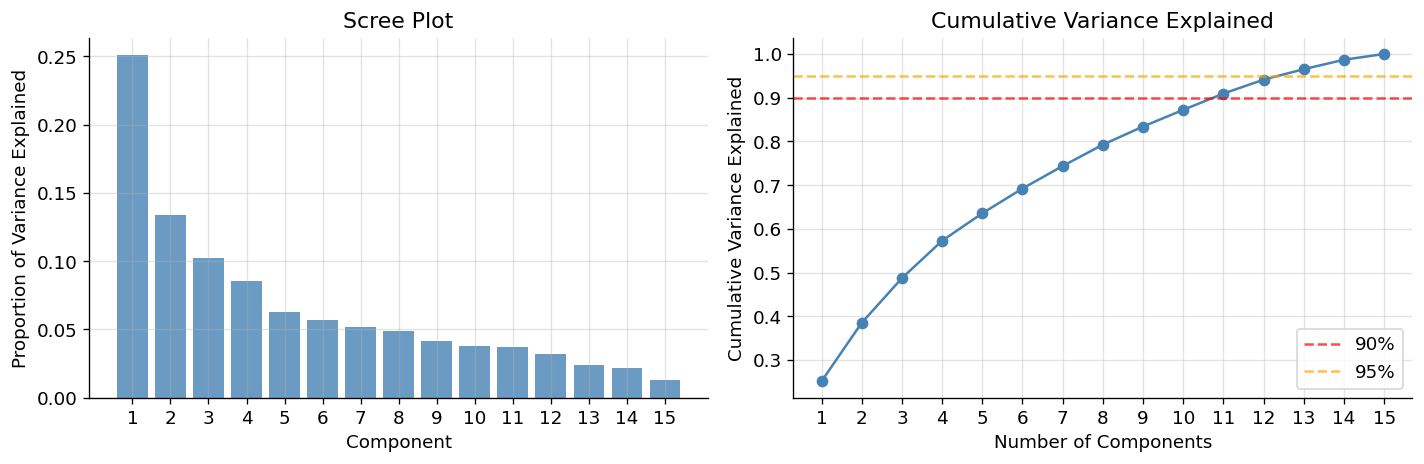

Variance explained per component:
f1: 0.2512 (cumulative: 0.2512)
f2: 0.1338 (cumulative: 0.3850)
f3: 0.1021 (cumulative: 0.4871)
f4: 0.0856 (cumulative: 0.5727)
f5: 0.0628 (cumulative: 0.6355)
f6: 0.0567 (cumulative: 0.6922)
f7: 0.0515 (cumulative: 0.7437)
f8: 0.0488 (cumulative: 0.7925)
f9: 0.0415 (cumulative: 0.8341)
f10: 0.0381 (cumulative: 0.8722)
f11: 0.0372 (cumulative: 0.9094)
f12: 0.0318 (cumulative: 0.9413)
f13: 0.0241 (cumulative: 0.9653)
f14: 0.0215 (cumulative: 0.9868)
f15: 0.0132 (cumulative: 1.0000)


In [81]:
# Appendix 5 - Exploratory PCA and Factor Analysis

# Split into training and holdout sets.
# Scaler and PCA are fit on training data only to prevent data leakage.
X_train = df_transformed.loc[TRAIN_START:TRAIN_END].drop(columns=['DGS10'])
X_hold = df_transformed.loc[HOLD_START:HOLD_END].drop(columns=['DGS10'])
z_train = df_transformed.loc[TRAIN_START:TRAIN_END, 'DGS10']
z_hold = df_transformed.loc[HOLD_START:HOLD_END, 'DGS10']

print(f'X_train shape: {X_train.shape}')
print(f'X_hold shape: {X_hold.shape}')
print(f'z_train shape: {z_train.shape}')
print(f'z_hold shape: {z_hold.shape}')

# Standardize - fit on training data only, transform both.
scaler = StandardScaler()
# scaler.fit_transform(X_train) - computes and stores on the scaler instance the mean and standard deviation
# of X_train.
X_train_scaled = scaler.fit_transform(X_train)
# scaler.transform(X_hold) - applies standardization, ((x - mu) / sigma) using the mean and standard deviation
# stored on the scaler instance from fit_transform(X_train).
X_hold_scaled = scaler.transform(X_hold)

# Fit PCA on training data only, retain all components for scree plot.
pca = PCA()
# pca.fit(X_train_scaled) - computes and stores on the pca instance the eigenvectors
# and eigenvalues of the covariance matrix of X_train_scaled.
pca.fit(X_train_scaled)

# Scree plot - variance explained per component.
n_components = len(pca.explained_variance_ratio_)
components = range(1, n_components + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left - variance explained per component.
axes[0].bar(components, pca.explained_variance_ratio_, color='steelblue', alpha=0.8)
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Proportion of Variance Explained')
axes[0].set_title('Scree Plot')
axes[0].set_xticks(components)

# Right - cumulative variance explained.
axes[1].plot(components, pca.explained_variance_ratio_.cumsum(), marker='o', color='steelblue')
axes[1].axhline(0.90, color='red', linestyle='--', alpha=0.7, label='90%')
axes[1].axhline(0.95, color='orange', linestyle='--', alpha=0.7, label='95%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained')
axes[1].set_title('Cumulative Variance Explained')
axes[1].set_xticks(components)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print variance explained per component.
print('Variance explained per component:')
for i, var in enumerate(pca.explained_variance_ratio_):
    cumvar = pca.explained_variance_ratio_[:i+1].sum()
    print(f'f{i+1}: {var:.4f} (cumulative: {cumvar:.4f})')


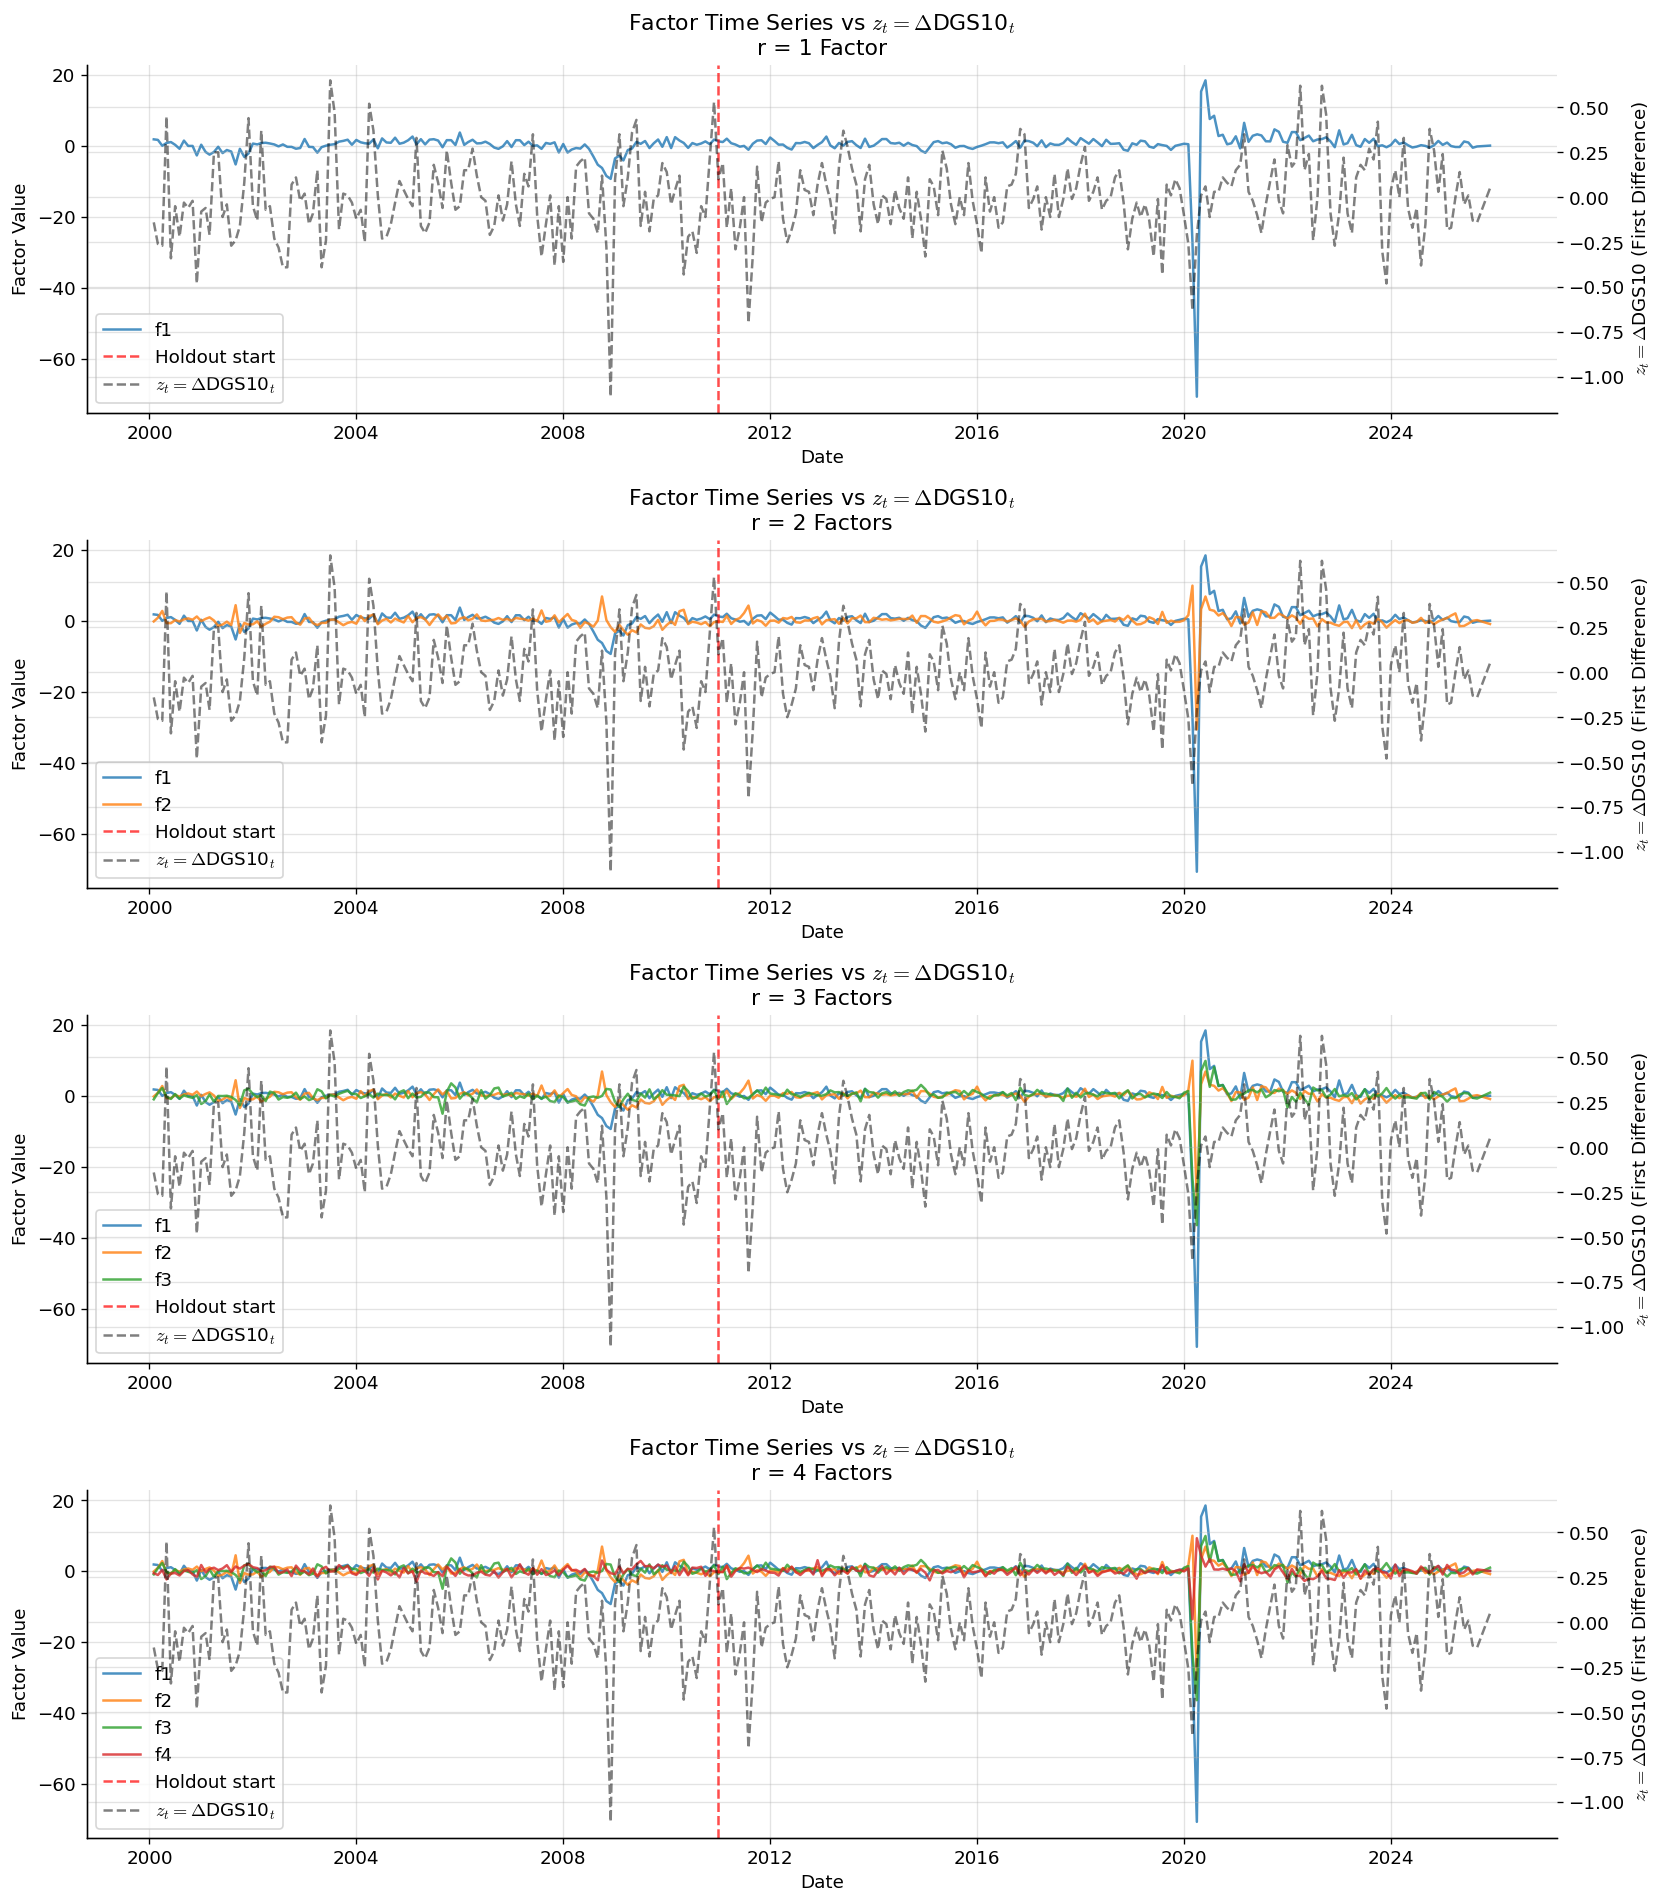

In [82]:
# Factor counts to evaluate.
# Both Stock and Watson (2002) and Swanson (Lecture 19, Econ 570, Spring 2026) note that a small number of
# factors, typically 1-3, are sufficient for macroeconomic forecasting. r = 4 is included
# for exploratory purposes given the scree plot above.
R_VALUES = [1, 2, 3, 4]

# Scale the full dataset for factor time series plots.
# Scaler was fit on training data only above, so the standardization uses the
# mean and standard deviation from X_train data.
X_full_scaled = scaler.transform(
    df_transformed.drop(columns=['DGS10'])
)

# For each r, extract factors from training data and plot factor time series.
fig, axes = plt.subplots(len(R_VALUES), 1, figsize=(14, 4 * len(R_VALUES)))

factors_dict = {}
for i, r in enumerate(R_VALUES):
    pca_r = PCA(n_components=r)
    # Compute and store eigenvectors.
    pca_r.fit(X_train_scaled)

    # Extract factors for full dataset.
    # Project the data onto the eigenvectors for factor analysis.
    F_full = pca_r.transform(X_full_scaled)
    F_df = pd.DataFrame(
        F_full,
        index=df_transformed.index,
        columns=[f'f{j+1}' for j in range(r)]
    )
    factors_dict[r] = F_df

    # Plot factor time series alongside z_t = delta DGS10.
    ax = axes[i]
    ax2 = ax.twinx()
    for col in F_df.columns:
        ax.plot(F_df.index, F_df[col], label=col, alpha=0.8)
    ax2.plot(df_transformed.index, df_transformed['DGS10'], color='black', linestyle='--', alpha=0.5, label='$z_t = \\Delta$DGS10$_t$')
    ax.axvline(pd.Timestamp(HOLD_START), color='red', linestyle='--', alpha=0.7, label='Holdout start')
    ax.set_title(f'Factor Time Series vs $z_t = \\Delta$DGS10$_t$\nr = {r} {"Factor" if r == 1 else "Factors"}')
    ax.set_xlabel('Date')
    ax.set_ylabel('Factor Value')
    ax2.set_ylabel('$z_t = \\Delta$DGS10 (First Difference)')
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

# Appendix 6 - Expanding Window Forecasting

For each value of $r \in \{1, 2, 3, 4\}$, the following diffusion index model is estimated
using an expanding window at each forecast origin $t$:

$$\hat{z}_{t+1|t} = \hat{\beta}_F' \hat{F}_t + \hat{\beta}_w z_{t-1}$$

where $\hat{F}_t$ is the $r \times 1$ vector of factors extracted via PCA from the
macroeconomic panel at time $t$, and $z_{t-1}$ is the lagged value of
$z_t = \Delta\text{DGS10}_t$. At each step $t$, the scaler and PCA are refit on data up to $t$ only, and $\hat{\beta}_F$
and $\hat{\beta}_w$ are estimated by OLS with HAC standard errors using automatic lag
selection following Newey and West (1987), as implemented in statsmodels via
`maxlags=None`.

The RW benchmark forecast is:

$$\hat{z}_{t+1|t} = 0$$

MSFE is computed over the holdout period for all five models - RW and factor models with
$r = 1, 2, 3, 4$ - and used to select the preferred model.

In [83]:
# Appendix 6 - Forecasting Loop
# Expanding window forecasting for RW benchmark and factor models with r = 1, 2, 3, 4.
# At each step t, the scaler and PCA are refit on data up to t to prevent data leakage.
# OLS is estimated with HAC standard errors with automatic lag selection following
# Newey and West (1987), as implemented in statsmodels via maxlags=None.

results_dict = {}

for r in R_VALUES:
    forecasts = []
    actuals = []
    forecast_dates = []

    # Get the integer index of the last training observation in df_transformed.
    train_end_idx = df_transformed.index.get_loc(df_transformed.loc[:TRAIN_END].index[-1])

    for t in range(train_end_idx, len(df_transformed) - 1):
        # Slice data up to and including t.
        df_t = df_transformed.iloc[:t+1]

        # Separate regressors and regressand.
        X_t = df_t.drop(columns=['DGS10']).copy()
        z_t = df_t['DGS10'].copy()

        # Refit scaler on X up to t, transform X up to t.
        scaler_t = StandardScaler()
        X_t_scaled = scaler_t.fit_transform(X_t)

        # Refit PCA on scaled X up to t, extract factors up to t.
        pca_t = PCA(n_components=r)
        F_t = pca_t.fit_transform(X_t_scaled)

        # Build regression DataFrame.
        df_reg = pd.DataFrame(
            F_t,
            index=df_t.index,
            columns=[f'f{j+1}' for j in range(r)]
        )
        # z_lag is the lagged value of z_t = delta DGS10_t.
        # z_t is already first differenced, so shift(1) gives z_{t-1}.
        df_reg['z_lag'] = z_t.shift(1)
        df_reg['z'] = z_t.values

        # Drop first row due to lag.
        df_reg = df_reg.dropna()

        # Fit OLS with HAC standard errors, automatic lag selection following
        # Newey and West (1987).
        factor_cols = ' + '.join([f'f{j+1}' for j in range(r)])
        model = smf.ols(f'z ~ {factor_cols} + z_lag', data=df_reg).fit(
            cov_type='HAC',
            cov_kwds={'maxlags': None}
        )

        # Forecast at origin t.
        # Scale X at time t using scaler fit on data up to t.
        x_t_scaled = scaler_t.transform(X_t.iloc[[-1]])
        f_t = pca_t.transform(x_t_scaled)
        # z_t is already first differenced, so z_t.iloc[-1] is z_{t-1} for the forecast.
        z_lag_t = z_t.iloc[-1]

        forecast_data = pd.DataFrame(
            f_t,
            columns=[f'f{j+1}' for j in range(r)]
        )
        forecast_data['z_lag'] = z_lag_t

        zhat = model.predict(forecast_data)[0]

        forecasts.append(zhat)
        actuals.append(df_transformed['DGS10'].iloc[t+1])
        forecast_dates.append(df_transformed.index[t+1])

    results_dict[r] = pd.DataFrame({
        'date': forecast_dates,
        'actual': actuals,
        'forecast': forecasts
    }).set_index('date')

# RW benchmark - in first differences the RW forecast is always zero.
rw_actuals = df_transformed['DGS10'].loc[HOLD_START:HOLD_END]
rw_forecasts = pd.Series(0.0, index=rw_actuals.index)
results_dict['RW'] = pd.DataFrame({
    'actual': rw_actuals,
    'forecast': rw_forecasts
})

# Compute MSFE for each model over the holdout period.
msfe_results = {}
for key, df_res in results_dict.items():
    df_hold = df_res.loc[HOLD_START:HOLD_END]
    msfe = ((df_hold['actual'] - df_hold['forecast']) ** 2).mean()
    msfe_results[key] = msfe

df_msfe = pd.DataFrame.from_dict(
    msfe_results,
    orient='index',
    columns=['MSFE']
).sort_values('MSFE')

print('MSFE - All Models')
print(f'Holdout period: {HOLD_START} to {HOLD_END}')
print(f'P = {len(results_dict["RW"])} forecasts')
display(df_msfe.style
    .format({'MSFE': '{:.6f}'})
    .highlight_min(subset=['MSFE'], color='lightgreen')
    .highlight_max(subset=['MSFE'], color='#ffcccc')
    .set_caption('MSFE - Factor Models vs RW Benchmark')
)

MSFE - All Models
Holdout period: 2011-01-01 to 2025-12-31
P = 178 forecasts


,MSFE
4,0.036440
3,0.036601
2,0.037245
RW,0.038290
1,0.039210


In [84]:
display(df_msfe.style
    .format({'MSFE': '{:.6f}'})
    .highlight_min(subset=['MSFE'], color='darkgreen')
    .highlight_max(subset=['MSFE'], color='red')
    .set_caption('MSFE - Factor Models vs RW Benchmark')
)

,MSFE
4,0.036440
3,0.036601
2,0.037245
RW,0.038290
1,0.039210


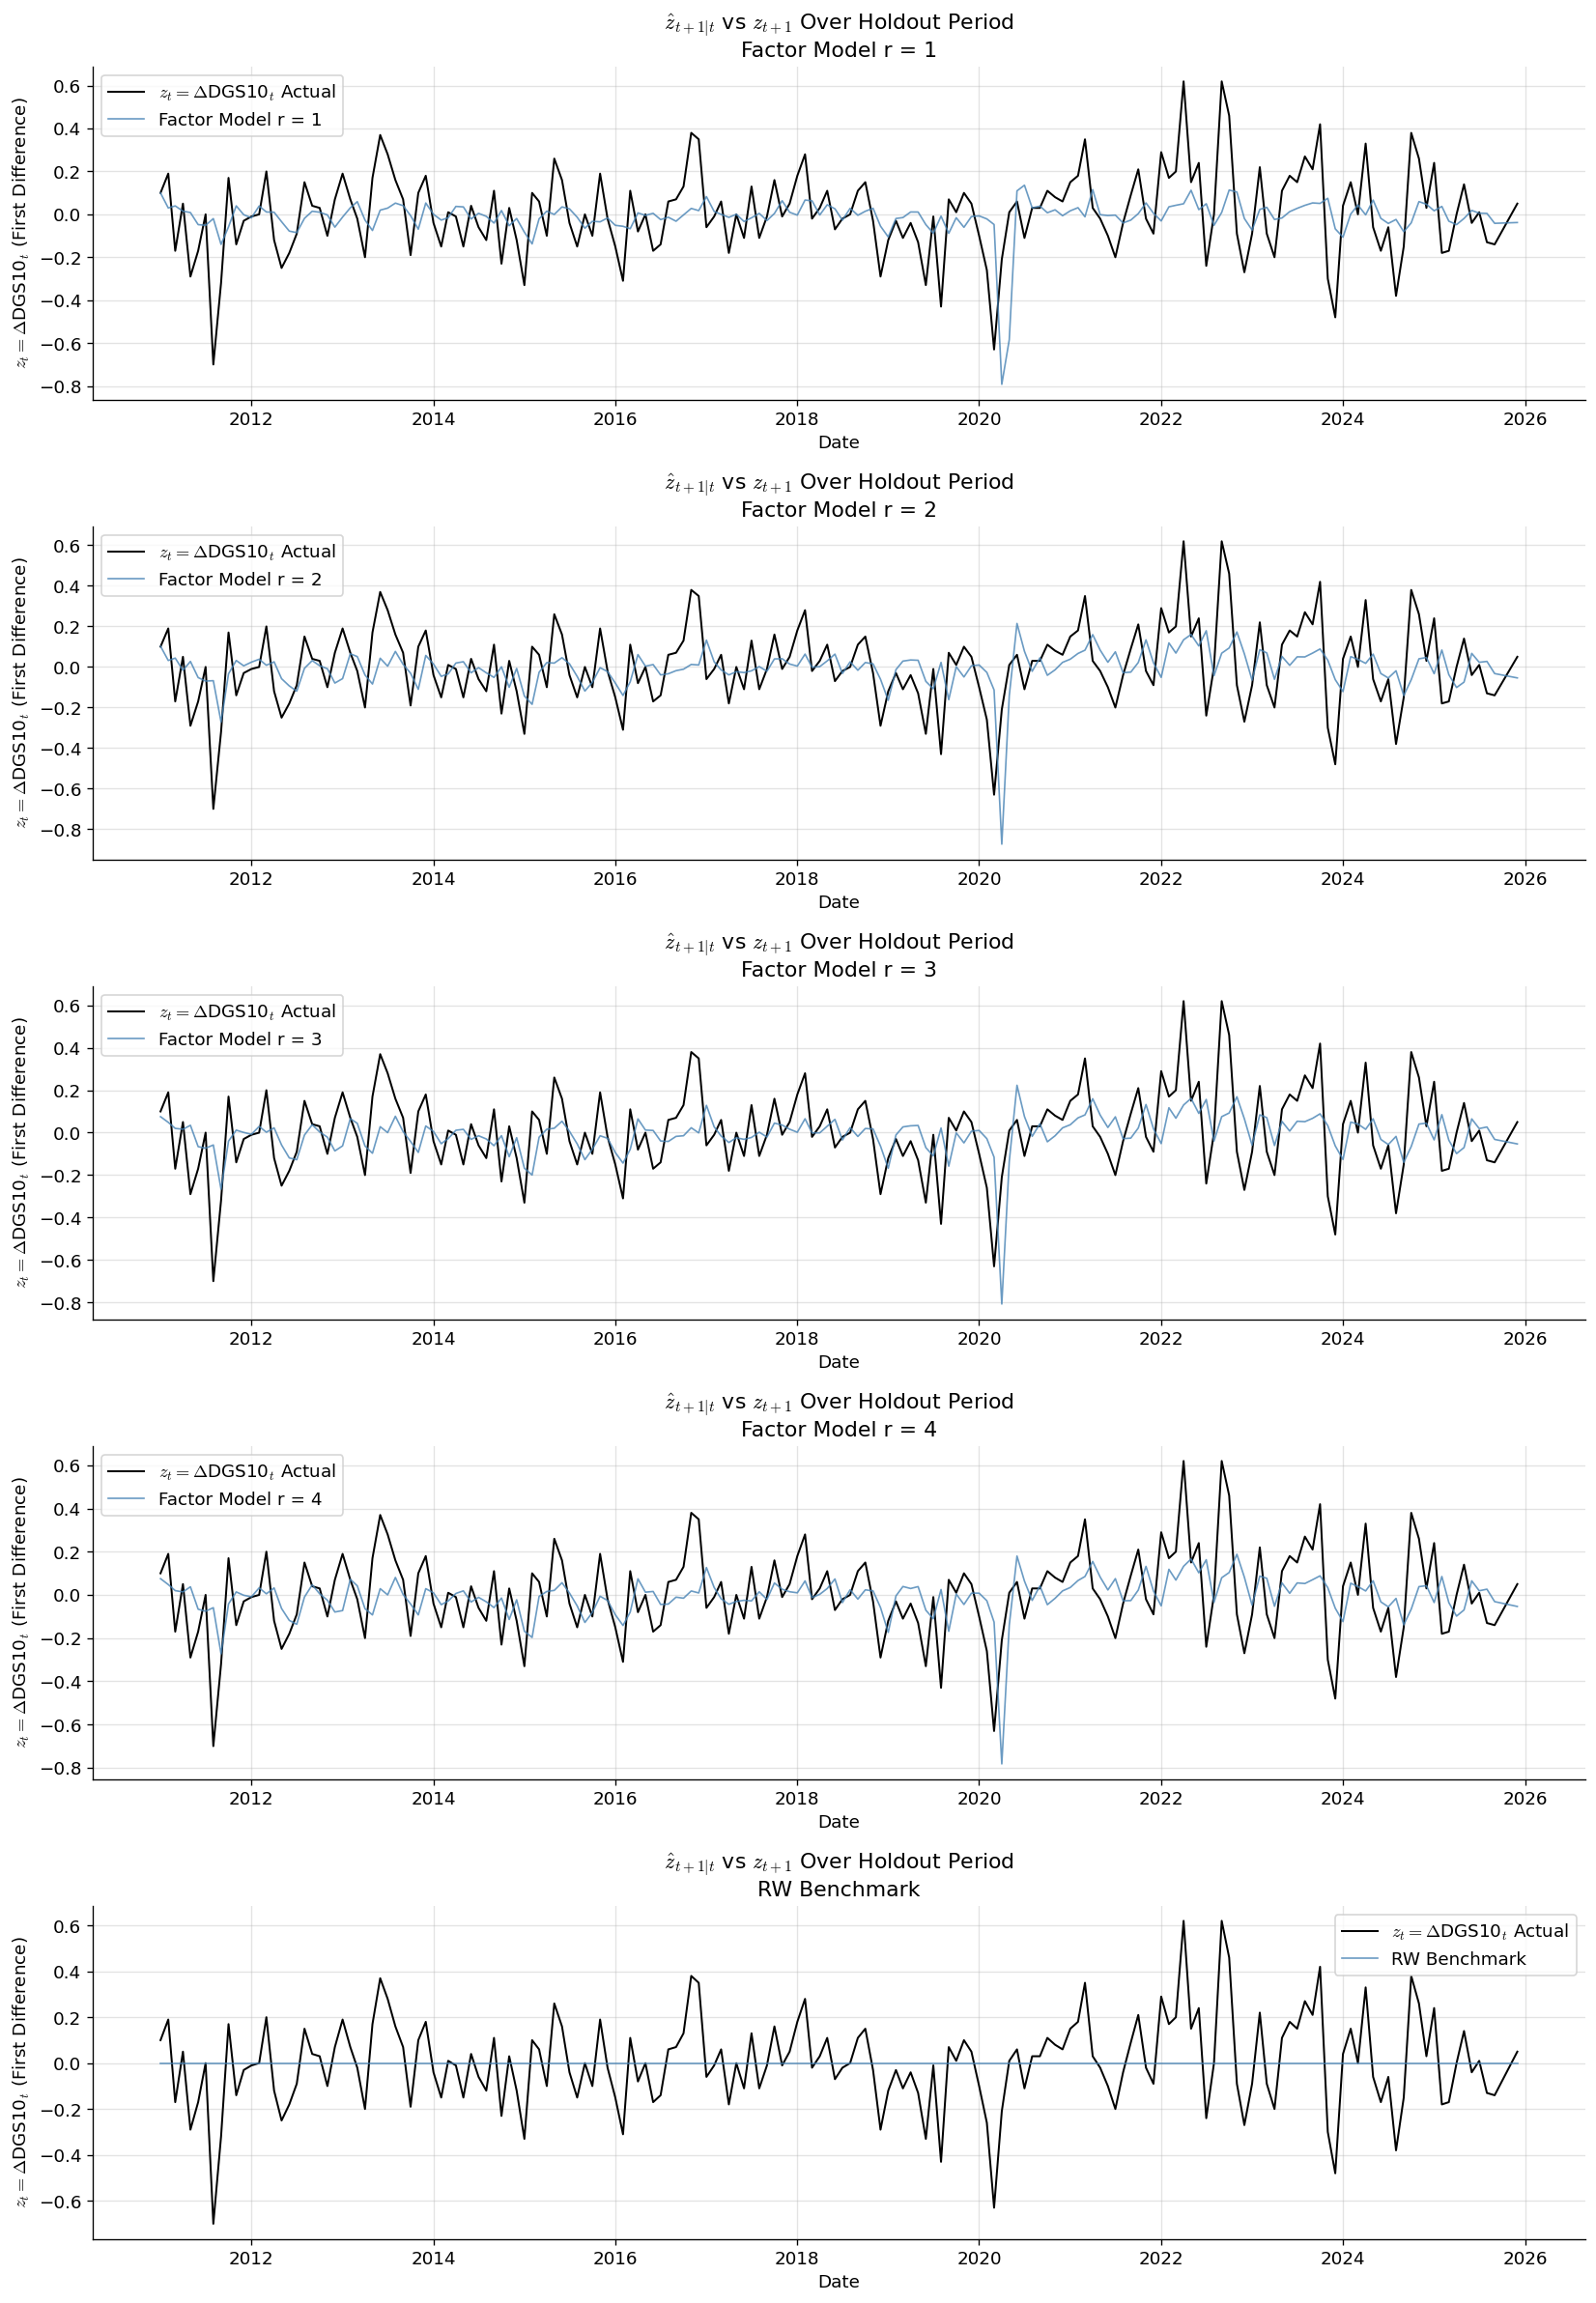

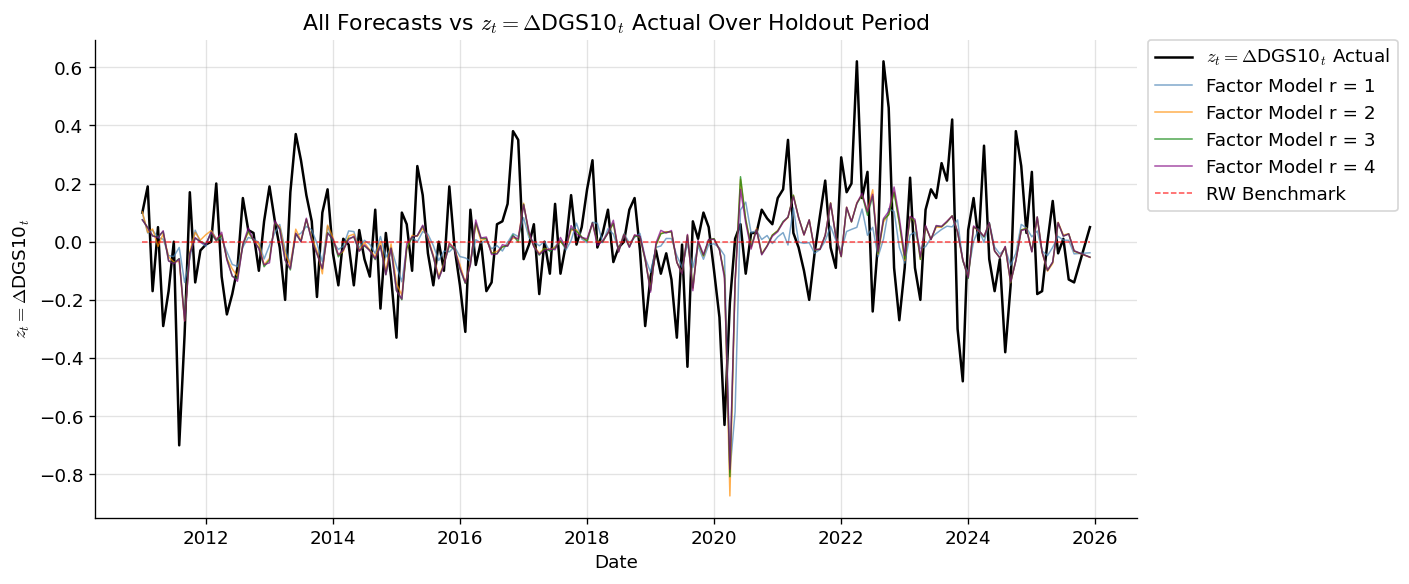

In [89]:
# Plot forecasts vs actuals for each model - individual subplots.
plot_models = [1, 2, 3, 4, 'RW']
fig, axes = plt.subplots(len(plot_models), 1, figsize=(14, 4 * len(plot_models)))

for i, key in enumerate(plot_models):
    df_plot = results_dict[key].loc[HOLD_START:HOLD_END]
    ax = axes[i]
    ax.plot(df_plot.index, df_plot['actual'], color='black', label='$z_t = \\Delta$DGS10$_t$ Actual', linewidth=1.2)
    ax.plot(df_plot.index, df_plot['forecast'], color='steelblue', linewidth=1.0, alpha=0.8,
            label='RW Benchmark' if key == 'RW' else f'Factor Model r = {key}')    
    ax.set_title(f'$\\hat{{z}}_{{t+1|t}}$ vs $z_{{t+1}}$ Over Holdout Period{"\nRW Benchmark" if key == "RW" else f"\nFactor Model r = {key}"}')
    ax.set_xlabel('Date')
    ax.set_ylabel('$z_t = \\Delta$DGS10$_t$ (First Difference)')
    ax.legend()

plt.tight_layout()
plt.show()

# All models on one plot.
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(results_dict[1].loc[HOLD_START:HOLD_END].index,
        results_dict[1].loc[HOLD_START:HOLD_END]['actual'],
        color='black', label='$z_t = \\Delta$DGS10$_t$ Actual', linewidth=1.5)

colors = {1: 'steelblue', 2: 'darkorange', 3: 'green', 4: 'purple'}
for key in [1, 2, 3, 4]:
    df_plot = results_dict[key].loc[HOLD_START:HOLD_END]
    ax.plot(df_plot.index, df_plot['forecast'], color=colors[key],
            label=f'Factor Model r = {key}', linewidth=0.9, alpha=0.7)

df_rw = results_dict['RW'].loc[HOLD_START:HOLD_END]
ax.plot(df_rw.index, df_rw['forecast'], color='red', linestyle='--',
        label='RW Benchmark', linewidth=0.9, alpha=0.7)

ax.set_title('All Forecasts vs $z_t = \\Delta$DGS10$_t$ Actual Over Holdout Period')
ax.set_xlabel('Date')
ax.set_ylabel('$z_t = \\Delta$DGS10$_t$')
ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# Appendix 7 - Diebold-Mariano Test for Predictive Accuracy

Following Diebold and Mariano (1995) and Swanson (Lecture 22, Econ 570, Spring 2026,
slide 15), the Diebold-Mariano (DM) test is used to formally test whether the factor
models produce statistically significantly different forecast accuracy from the RW
benchmark. The null and alternative hypotheses are:

$$H_0: E[g(\hat{u}_{0,t+h}) - g(\hat{u}_{1,t+h})] = 0$$
$$H_A: E[g(\hat{u}_{0,t+h}) - g(\hat{u}_{1,t+h})] \neq 0$$

where $g(\hat{u}) = \hat{u}^2$ is the quadratic loss function consistent with MSFE,
$\hat{u}_{0,t+h}$ is the RW forecast error, and $\hat{u}_{1,t+h}$ is the factor model
forecast error. The test statistic is:

$$DM_P = \frac{\bar{d}_t}{\hat{\sigma}_{\bar{d}_t}} \rightarrow N(0,1)$$

where:
- $d_t = g(\hat{u}_{0,t+h}) - g(\hat{u}_{1,t+h})$ is the loss differential at time $t$
- $\bar{d}_t = \frac{1}{P}\sum_{t=R+1}^{T} d_t$ is the mean loss differential
- $\hat{\sigma}_{\bar{d}_t} = \frac{\hat{\sigma}_{d_t}}{\sqrt{P}}$ is the HAC standard
  error of $\bar{d}_t$

A positive $DM_P$ statistic indicates the factor model has lower MSFE than the RW.
A p-value below 0.05 allows rejection of $H_0$ and conclusion that the factor model
produces statistically significantly better forecasts than the RW benchmark.

The factor model with $r = 1$ fails to beat the RW benchmark on MSFE, suggesting that a
single macro factor adds noise rather than predictive signal. The factor models with
$r = 2, 3, 4$ produce lower MSFE than the RW benchmark over the holdout period, with the
$r = 4$ model achieving the lowest MSFE. However, the Diebold-Mariano test fails to reject
the null hypothesis of equal predictive accuracy at the 5% significance level for all
models. This is consistent with the Efficient Markets Hypothesis - the 10-year U.S.
Treasury rate appears to follow a Random Walk, and publicly available macroeconomic
information does not provide statistically significant predictive power beyond what the
rate's own history captures. This finding is consistent with the broader forecasting
literature, where beating the RW for interest rates remains difficult even with large macro
panels, as noted in Swanson (Lecture 22, Econ 570, Spring 2026).

# Appendix 7 - Diebold-Mariano Test for Predictive Accuracy

Diebold-Mariano test methodology, results, and discussion are presented in the
**Methodology and Empirical Results** section.

In [90]:
# Appendix 7 - Diebold-Mariano Test for Predictive Accuracy
# Following Diebold and Mariano (1995) and Swanson (Lecture 22, Econ 570, Spring 2026, slide 15).
# H0: equal predictive accuracy between RW and factor model.
# HA: unequal predictive accuracy.
# Loss function: quadratic loss g(u) = u^2, consistent with MSFE.

dm_results = []

rw_errors = (results_dict['RW'].loc[HOLD_START:HOLD_END]['actual'] -
             results_dict['RW'].loc[HOLD_START:HOLD_END]['forecast'])

for r in R_VALUES:
    factor_errors = (results_dict[r].loc[HOLD_START:HOLD_END]['actual'] -
                     results_dict[r].loc[HOLD_START:HOLD_END]['forecast'])

    # Loss differential d_t = g(u_RW) - g(u_factor) = u_RW^2 - u_factor^2.
    # Positive d_t means RW has higher loss, ie factor model is better at time t.
    d_t = rw_errors**2 - factor_errors**2

    # Mean loss differential.
    d_bar = d_t.mean()

    # HAC standard deviation of d_t via OLS regression on a constant with HAC errors.
    # This gives us the HAC variance of d_bar directly.
    model_dm = smf.ols('d ~ 1', data=d_t.rename('d').to_frame()).fit(
        cov_type='HAC',
        cov_kwds={'maxlags': None}
    )

    # Standard error of d_bar = HAC std of d_t / sqrt(P).
    sigma_d_bar = model_dm.bse['Intercept']

    # DM test statistic.
    DM = d_bar / sigma_d_bar

    # Two-sided p-value from N(0,1).
    p_value = 2 * (1 - scipy.stats.norm.cdf(abs(DM)))

    dm_results.append({
        'r': r,
        'MSFE_factor': msfe_results[r],
        'MSFE_RW': msfe_results['RW'],
        'DM': DM,
        'p_value': p_value,
        'beats_RW': msfe_results[r] < msfe_results['RW'],
        'significant': p_value < 0.05
    })

df_dm = pd.DataFrame(dm_results).set_index('r')

print('Diebold-Mariano Test Results')
print(f'Holdout period: {HOLD_START} to {HOLD_END}, P = {len(rw_errors)} forecasts')
display(df_dm.style
    .format({
        'MSFE_factor': '{:.6f}',
        'MSFE_RW': '{:.6f}',
        'DM': '{:.4f}',
        'p_value': '{:.4f}'
    })
    .highlight_min(subset=['MSFE_factor'], color='lightgreen')
    .set_caption('Diebold-Mariano Test - Factor Models vs RW Benchmark')
)

Diebold-Mariano Test Results
Holdout period: 2011-01-01 to 2025-12-31, P = 178 forecasts


,MSFE_factor,MSFE_RW,DM,p_value,beats_RW,significant
r,,,,,,
1,0.039210,0.038290,-0.2622,0.7932,False,False
2,0.037245,0.038290,0.3910,0.6958,True,False
3,0.036601,0.038290,0.7193,0.4720,True,False
4,0.036440,0.038290,0.8311,0.4059,True,False


In [91]:
display(df_dm.style
    .format({
        'MSFE_factor': '{:.6f}',
        'MSFE_RW': '{:.6f}',
        'DM': '{:.4f}',
        'p_value': '{:.4f}'
    })
    .highlight_min(subset=['MSFE_factor'], color='darkgreen')
    .set_caption('Diebold-Mariano Test - Factor Models vs RW Benchmark')
)

,MSFE_factor,MSFE_RW,DM,p_value,beats_RW,significant
r,,,,,,
1,0.039210,0.038290,-0.2622,0.7932,False,False
2,0.037245,0.038290,0.3910,0.6958,True,False
3,0.036601,0.038290,0.7193,0.4720,True,False
4,0.036440,0.038290,0.8311,0.4059,True,False


# Conclusion

The factor model with $r = 1$ fails to beat the RW benchmark on MSFE, suggesting that a
single macro factor adds noise rather than predictive signal. The factor models with
$r = 2, 3, 4$ produce lower MSFE than the RW benchmark over the holdout period, with the
$r = 4$ model achieving the lowest MSFE. However, the Diebold-Mariano test fails to reject
the null hypothesis of equal predictive accuracy at the 5% significance level for all
models, as shown in Appendix 7. This is consistent with the Efficient Markets Hypothesis -
the 10-year U.S. Treasury rate appears to follow a Random Walk, and publicly available
macroeconomic information does not provide statistically significant predictive power beyond
what the rate's own history captures. This finding is consistent with the broader
forecasting literature, where beating the RW for interest rates remains difficult even with
large macro panels, as noted in Swanson (Lecture 22, Econ 570, Spring 2026).